<a href="https://colab.research.google.com/github/sahdahx/PDS/blob/main/Hands_On_Week_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **HANDS ON – WEEK 3 | 23 Februari 2026**

**DATA FRAMES, IMPORTING AND INSPECTING DATA**

(Praktikum menggunakan Python)

Learning Outcomes:

1.   Mencari & memuat dataset
2.   Memahami struktur data
1.   Membersihkan data
2.   Memanipulasi variabel
1.   Melakukan agregasi
2.   Membuat visualisasi sederhana

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

***1 . The DataFrame Data Structure***

Struktur data utama dalam Pandas adalah objek *DataFrame*. *DataFrame* pada dasarnya merupakan struktur data berbentuk tabel, yang terdiri atas baris dan kolom. Setiap baris memiliki indeks tertentu untuk mengaksesnya. Struktur data *DataFrame* dapat dipandang sebagai sebuah spreadsheet, tetapi dengan fleksibilitas yang jauh lebih tinggi.

In [ ]:
data = {
    'year': [
        2010, 2011, 2012,
        2010, 2011, 2012,
        2010, 2011, 2012
    ],
    'team': [
        'FCBarcelona', 'FCBarcelona', 'FCBarcelona',
        'RMadrid', 'RMadrid', 'RMadrid',
        'ValenciaCF', 'ValenciaCF', 'ValenciaCF'
    ],
    'wins': [30, 28, 32, 29, 32, 26, 21, 17, 19],
    'draws': [6, 7, 4, 5, 4, 7, 8, 10, 8],
    'losses': [2, 3, 2, 4, 2, 5, 9, 11, 11]
}

football = pd.DataFrame(
    data,
    columns=['year', 'team', 'wins', 'draws', 'losses']
)

football


,year,team,wins,draws,losses
0,2010,FCBarcelona,30,6,2
1,2011,FCBarcelona,28,7,3
2,2012,FCBarcelona,32,4,2
3,2010,RMadrid,29,5,4
4,2011,RMadrid,32,4,2
5,2012,RMadrid,26,7,5
6,2010,ValenciaCF,21,8,9
7,2011,ValenciaCF,17,10,11
8,2012,ValenciaCF,19,8,11


**2. Membaca data**

Cara membaca *file CSV* adalah dengan memanggil metode *read_csv*. Biasanya, file CSV memiliki header yang berisi nama-nama kolom. Jika demikian, kita dapat menggunakan parameter *usecols* untuk memilih kolom-kolom mana saja dalam file yang akan digunakan.
Selain itu, Pandas juga menyediakan fungsi untuk membaca file dengan berbagai format lain seperti Excel, HDF5, file bertab (tabulated files), bahkan isi dari clipboard, yaitu melalui fungsi *read_excel*(), read_hdf(), *read_table*(), dan *read_clipboard*(). Hasil pembacaan file tersebut akan disimpan dalam bentuk struktur DataFrame.

In [ ]:
df = pd.read_csv("Students_Performance_knn.csv")

**3. Tampilan data**

Untuk melihat seperti apa tampilan data, kita dapat menggunakan metode *head()*, yang secara default menampilkan lima baris pertama. Serta metode *tail()*, yang secara default menampilkan lima baris terakhir dari data.

In [ ]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [ ]:
df.tail()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77
999,female,group D,some college,free/reduced,none,77,86,86


In [ ]:
df

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77


**4. Deskripsi Data**

Untuk mengetahui nama-nama kolom atau nama indeks, gunakan atribut DataFrame *columns* dan *index* secara berurutan. Untuk memperoleh informasi statistik secara cepat untuk semua kolom numerik dalam sebuah DataFrame, kita dapat menggunakan fungsi *describe()*. Hasilnya akan menampilkan jumlah data (*count*), nilai rata-rata (*mean*), simpangan baku (*standard deviation*), nilai minimum dan maksimum, serta persentil—secara default persentil ke-25, ke-50, dan ke-75—untuk semua nilai pada setiap kolom atau Series.

In [ ]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


**5. Memilih Data (*Selecting* *Data*)**

Untuk memilih sebagian data (*subset*) dari sebuah DataFrame, kita perlu menunjukkan subset tersebut dengan menggunakan tanda kurung siku ([ ]) setelah nama DataFrame. *Subset* ini dapat ditentukan dengan beberapa cara.

Jika ingin memilih hanya satu kolom dari sebuah DataFrame, kita cukup menuliskan nama kolom tersebut di dalam tanda kurung siku. Hasil yang diperoleh bukan lagi berupa DataFrame, melainkan struktur data Series, karena hanya satu kolom yang diambil.

In [ ]:
df['math score']

,math score
0,72
1,69
2,90
3,47
4,76
...,...
995,88
996,62
997,59
998,68


Untuk memilih sebagian baris (*subset of rows*) dari sebuah DataFrame, dapat dilakukan dengan menentukan rentang baris yang dipisahkan oleh tanda titik dua (:) di dalam tanda kurung siku. Cara ini dikenal sebagai slice baris (*row slicing*).

In [ ]:
df[10:14]

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
10,male,group C,associate's degree,standard,none,58,54,52
11,male,group D,associate's degree,standard,none,40,52,43
12,female,group B,high school,standard,none,65,81,73
13,male,group A,some college,standard,completed,78,72,70


Untuk memilih sebagian kolom dan baris dengan menggunakan label sebagai acuan, bukan berdasarkan posisi, maka kita dapat menggunakan pengindeksan:

.loc → label-based indexing

.iloc → position-based indexing

In [ ]:
df.loc[7:12, ['lunch', 'math score']]

,lunch,math score
7,free/reduced,40
8,free/reduced,64
9,free/reduced,38
10,standard,58
11,standard,40
12,standard,65


In [ ]:
df.iloc[7:13, [4]]

,test preparation course
7,none
8,completed
9,none
10,none
11,none
12,none


**6. Penyaringan Data (Filtering Data)**

Cara lain untuk memilih sebagian data (*subset*) adalah dengan menggunakan Boolean indexing. Teknik ini umumnya dikenal sebagai filter.
Sebagai contoh, jika kita ingin menyaring '*math score*' yang kurang dari atau sama dengan 89.

In [ ]:
df[df['math score'] > 89]

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
2,female,group B,master's degree,standard,none,90,95,93
34,male,group E,some college,standard,none,97,87,82
104,male,group C,some college,standard,completed,98,86,90
114,female,group E,bachelor's degree,standard,completed,99,100,100
121,male,group B,associate's degree,standard,completed,91,89,92
149,male,group E,associate's degree,free/reduced,completed,100,100,93
165,female,group C,bachelor's degree,standard,completed,96,100,100
171,male,group E,some high school,standard,none,94,88,78
179,female,group D,some high school,standard,completed,97,100,100
233,male,group E,some high school,standard,none,92,87,78


**7. Menyaring Nilai yang Hilang (*Filtering Missing Values*)**

Pandas menggunakan nilai khusus NaN (*not a number*) untuk merepresentasikan data yang hilang (*missing values*).

Salah satu karakteristik penting dari nilai NaN adalah bahwa dua nilai NaN tidak pernah dianggap sama. Karena sifat ini, satu-satunya cara yang aman untuk memeriksa apakah suatu nilai dalam DataFrame merupakan nilai yang hilang adalah dengan menggunakan fungsi *isnull*().

Fungsi ini dapat digunakan untuk menyaring baris-baris yang mengandung nilai yang hilang.

In [ ]:
#@title cek missing value
df.isnull().sum()

,0
gender,0
race/ethnicity,0
parental level of education,0
lunch,25
test preparation course,0
math score,0
reading score,0
writing score,0


In [ ]:
#@title menyaring missing values pada kolom Lunch
df[df['lunch'].isnull()]

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
6,female,group B,some college,NaN,completed,88,95,92
41,female,group C,associate's degree,NaN,none,58,73,68
53,male,group D,high school,NaN,none,88,78,75
70,female,group D,some college,NaN,completed,58,63,73
95,male,group C,associate's degree,NaN,completed,78,81,82
115,male,group C,high school,NaN,none,84,77,74
144,male,group D,some college,NaN,none,88,73,78
173,female,group C,associate's degree,NaN,none,63,67,70
188,male,group B,some high school,NaN,none,48,52,45
209,female,group B,some college,NaN,none,58,61,66


**8. Merangkum Data Numerik**

Setelah kita mengetahui cara memilih data yang diinginkan, langkah berikutnya adalah memahami bagaimana merangkum data numerik tersebut. Salah satu cara paling sederhana adalah melakukan operasi pada kolom atau baris dengan menggunakan fungsi agregasi.
Hasil dari fungsi-fungsi tersebut, jika diterapkan pada satu baris atau satu kolom, selalu berupa sebuah nilai numerik.
Sementara itu, jika suatu fungsi diterapkan pada seluruh DataFrame atau pada bagian tertentu dari baris dan kolom, kita dapat menentukan apakah fungsi tersebut akan diterapkan pada baris untuk setiap kolom (dengan menetapkan parameter axis=0 saat memanggil fungsi), atau diterapkan pada kolom untuk setiap baris (dengan menetapkan parameter axis=1).

List of most common aggregation functions

count() : Number of non-null observations

sum() : Sum of values

mean() : Mean of values

median() : Arithmetic median of values

min() : Minimum

max() : Maximum

prod() : Product of values

std() : Unbiased standard deviation

var() : Unbiased variance

In [ ]:
#@title rangkuman data numerik
df.count()

,0
gender,1000
race/ethnicity,1000
parental level of education,1000
lunch,975
test preparation course,1000
math score,1000
reading score,1000
writing score,1000


In [ ]:
#@title Nilai maksimum dari variabel Math Score
df['math score'].max()

100

In [ ]:
#@title Nilai maksimum dari data numerik
df.max(numeric_only=True)

,0
math score,100
reading score,100
writing score,100


In [ ]:
df.select_dtypes(include='number').max()

,0
math score,100
reading score,100
writing score,100


In [ ]:
#@title Membagi setiap nilai pada kolom math score dengan 100
a = df['math score']/100
a.head()

,math score
0,0.72
1,0.69
2,0.90
3,0.47
4,0.76


In [ ]:
#@title Mengkuadratkan reading score
b = df['reading score'].apply(np.square)
b.head()

,reading score
0,5184
1,8100
2,9025
3,3249
4,6084


Jika kita perlu merancang fungsi khusus untuk diterapkan pada data, kita dapat menuliskan fungsi tersebut secara langsung dalam bentuk fungsi in-line, yang biasa dikenal sebagai fungsi lambda (λ-function). Fungsi lambda adalah fungsi tanpa nama.
Untuk membuat fungsi lambda, kita hanya perlu menentukan parameter yang diterimanya, yang dituliskan setelah kata kunci lambda dan sebelum tanda titik dua (:).
Pada contoh berikutnya, hanya diperlukan satu parameter, yaitu nilai dari setiap elemen pada kolom Value. Nilai yang dikembalikan oleh fungsi tersebut adalah kuadrat dari nilai tersebut.

In [ ]:
#@title Mengkuadratkan writing dengan fungsi lambda score
c = df['writing score'].apply(lambda d:d**2)
c.head()

,writing score
0,5476
1,7744
2,8649
3,1936
4,5625


In [ ]:
#@title Menerapkan transformasi logaritma natural ke setiap nilai pada kolom writing score
d = df['writing score'].apply(lambda d: np.log(d + 1))
d.head()

,writing score
0,4.317488
1,4.488636
2,4.543295
3,3.806662
4,4.330733


**9. Menghapus Kolom**

untuk menghapus kolom tersebut dari DataFrame, dapat menggunakan fungsi *drop*. Fungsi ini akan menghapus baris yang ditentukan jika parameter axis=0, atau menghapus kolom yang ditentukan jika axis=1.
Jika kita tidak ingin mempertahankan nilai lama dan ingin langsung menimpa DataFrame yang ada, kita dapat mengatur parameter inplace menjadi True.

In [ ]:
#@title menghapus kolom lunch
dfhapus = df.drop('lunch', axis=1)
dfhapus.head()

,gender,race/ethnicity,parental level of education,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,none,72,72,74
1,female,group C,some college,completed,69,90,88
2,female,group B,master's degree,none,90,95,93
3,male,group A,associate's degree,none,47,57,44
4,male,group C,some college,none,76,78,75


In [ ]:
#@title Menghapus baris dengan index 0
df.drop(0, axis=0)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
5,female,group B,associate's degree,standard,none,71,83,78
...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77


**10. Menambah Baris**

Untuk menambahkan baris baru di bagian bawah DataFrame, dapat menggunakan fungsi *concat* pada Pandas. Fungsi ini menerima sebagai argumen sebuah baris baru yang direpresentasikan dalam bentuk dictionary, di mana setiap key merupakan nama kolom dan setiap value merupakan nilai yang sesuai untuk kolom tersebut.
Perlu diperhatikan bahwa kita harus mengatur parameter ignore_index menjadi True pada metode *concat*. Jika tidak, baris baru tersebut akan diberi indeks 0 secara otomatis, yang dapat menimbulkan kesalahan apabila indeks tersebut sudah ada sebelumnya.



In [ ]:
df = pd.concat([df, pd.DataFrame([{
    'gender': 'female',
    'race/ethnicity': 'group B',
    'parental level of education': "bachelor's degree",
    'lunch': 'free/reduced',
    'test preparation course': 'completed',
    'math score': 88,
    'reading score': 92,
    'writing score': 90
}])], ignore_index=True)

In [ ]:
df

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
...,...,...,...,...,...,...,...,...
999,female,group D,some college,free/reduced,none,77,86,86
1000,female,group B,bachelor's degree,NaN,completed,88,92,90
1001,female,group B,bachelor's degree,NaN,completed,88,92,90
1002,female,group B,bachelor's degree,standard,completed,88,92,90


In [ ]:
df.loc[len(df)] = [
    'female',
    'group B',
    "bachelor's degree",
    'standard',
    'completed',
    88,
    92,
    90
]

In [ ]:
df

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
...,...,...,...,...,...,...,...,...
1000,female,group B,bachelor's degree,NaN,completed,88,92,90
1001,female,group B,bachelor's degree,NaN,completed,88,92,90
1002,female,group B,bachelor's degree,standard,completed,88,92,90
1003,female,group B,bachelor's degree,free/reduced,completed,88,92,90


In [ ]:
#@title Menghapus baris terakhir
df.drop(max(df.index), axis=0, inplace=True)

In [ ]:
df

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
...,...,...,...,...,...,...,...,...
998,female,group D,some college,standard,completed,68,78,77
999,female,group D,some college,free/reduced,none,77,86,86
1000,female,group B,bachelor's degree,NaN,completed,88,92,90
1001,female,group B,bachelor's degree,NaN,completed,88,92,90


In [ ]:
#@title Menghapus 2 baris terakhir
df = df.iloc[:-2]

In [ ]:
df

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
...,...,...,...,...,...,...,...,...
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77
999,female,group D,some college,free/reduced,none,77,86,86


**11. Menghapus nilai yang hilang (missing values)**

Fungsi drop() juga digunakan untuk menghapus nilai yang hilang (missing values) dengan menerapkannya pada hasil dari fungsi isnull().

In [ ]:
#@title cek missing value
df.isnull().sum()

,0
gender,0
race/ethnicity,0
parental level of education,0
lunch,26
test preparation course,0
math score,0
reading score,0
writing score,0


In [ ]:
df[df.isnull().any(axis=1)]

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
6,female,group B,some college,NaN,completed,88,95,92
41,female,group C,associate's degree,NaN,none,58,73,68
53,male,group D,high school,NaN,none,88,78,75
70,female,group D,some college,NaN,completed,58,63,73
95,male,group C,associate's degree,NaN,completed,78,81,82
115,male,group C,high school,NaN,none,84,77,74
144,male,group D,some college,NaN,none,88,73,78
173,female,group C,associate's degree,NaN,none,63,67,70
188,male,group B,some high school,NaN,none,48,52,45
209,female,group B,some college,NaN,none,58,61,66


In [ ]:
dfdrop = df.dropna(ignore_index=True)

In [ ]:
dfdrop

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
...,...,...,...,...,...,...,...,...
970,female,group E,master's degree,standard,completed,88,99,95
971,male,group C,high school,free/reduced,none,62,55,55
972,female,group C,high school,free/reduced,completed,59,71,65
973,female,group D,some college,standard,completed,68,78,77


**12. Pengurutan (Sorting)**

Hal penting lainnya yang diperlukan saat memeriksa data adalah melakukan pengurutan berdasarkan kolom. Kita dapat mengurutkan sebuah DataFrame menggunakan kolom apa pun dengan menggunakan fungsi *sort*.

In [ ]:
#@title Mengurutkan data mulai dari nilai tertinggi
df.sort_values(by='math score', ascending=False, inplace=True)
df

/tmp/ipython-input-302537568.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.sort_values(by='math score', ascending=False, inplace=True)


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
916,male,group E,bachelor's degree,standard,completed,100,100,100
451,female,group E,some college,standard,none,100,92,97
458,female,group E,bachelor's degree,standard,none,100,100,100
149,male,group E,associate's degree,free/reduced,completed,100,100,93
625,male,group D,some college,standard,completed,100,97,99
...,...,...,...,...,...,...,...,...
145,female,group C,some college,free/reduced,none,22,39,33
787,female,group B,some college,standard,none,19,38,32
17,female,group B,some high school,free/reduced,none,18,32,28
980,female,group B,high school,free/reduced,none,8,24,23


In [ ]:
#@title Mengurutkan data mulai dari nilai terendah
df.sort_values(by='math score', ascending=True, inplace=True)
df

/tmp/ipython-input-1061513837.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.sort_values(by='math score', ascending=True, inplace=True)


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
59,female,group C,some high school,free/reduced,none,0,17,10
980,female,group B,high school,free/reduced,none,8,24,23
17,female,group B,some high school,free/reduced,none,18,32,28
787,female,group B,some college,standard,none,19,38,32
145,female,group C,some college,free/reduced,none,22,39,33
...,...,...,...,...,...,...,...,...
149,male,group E,associate's degree,free/reduced,completed,100,100,93
625,male,group D,some college,standard,completed,100,97,99
458,female,group E,bachelor's degree,standard,none,100,100,100
451,female,group E,some college,standard,none,100,92,97


**13. Pengelompokan Data (Grouping Data)**

untuk mengelompokkan data berdasarkan kriteria tertentu gunakan fungsi **groupby**

Agar hasilnya menjadi DataFrame yang “utuh”, kita perlu menerapkan sebuah **fungsi agregasi**. Fungsi agregasi ini akan diterapkan pada seluruh nilai dalam kelompok yang sama.

Sebagai contoh, jika kita ingin memperoleh DataFrame yang menampilkan **rata-rata (mean)** nilai untuk setiap negara selama seluruh tahun pengamatan, kita dapat mengelompokkan data berdasarkan negara dan menggunakan fungsi **mean** sebagai metode agregasi. Hasilnya adalah sebuah DataFrame dengan negara sebagai index dan nilai rata-rata sebagai kolom.


In [ ]:
#@title Mengelompokkan data berdasarkan rata-rata math score per race/ethnicity
group = df[['race/ethnicity', 'math score']].groupby('race/ethnicity').mean()
group

,math score
race/ethnicity,
group A,61.629213
group B,63.581152
group C,64.463950
group D,67.362595
group E,73.821429


**14. Menata Ulang Data (Rearranging Data)**

Sampai saat ini, index yang digunakan hanyalah penomoran baris yang tidak memiliki banyak makna. Kita dapat mengubah susunan data dengan mendistribusikan ulang index dan kolom agar data lebih mudah dimanipulasi, yang biasanya juga menghasilkan kinerja yang lebih baik.
Kita dapat menata ulang data menggunakan fungsi pivot_table. Dengan fungsi ini, kita bisa menentukan kolom mana yang akan menjadi index baru, nilai (values), dan kolom baru. Rearranging Data untuk pengelompokan dan mengubah struktur

In [ ]:
#@title Rata-rata skor berdasarkan gender
pivot_gender = df.pivot_table(
    index='gender',
    values=['math score', 'reading score', 'writing score'],
    aggfunc='mean'
)

pivot_gender

,math score,reading score,writing score
gender,,,
female,63.680154,72.645472,72.500963
male,68.728216,65.473029,63.311203


In [ ]:
#@title Rata-rata math score berdasarkan gender dan test preparation
pivot_prep = df.pivot_table(
    index='gender',
    columns='test preparation course',
    values='math score',
    aggfunc='mean'
)

pivot_prep

test preparation course,completed,none
gender,,
female,67.308108,61.670659
male,72.339080,66.688312


In [ ]:
#@title Rata-rata reading score berdasarkan gender dan race/ethnicity
pivot_race_gender = df.pivot_table(
    index='race/ethnicity',
    columns='gender',
    values='reading score',
    aggfunc='mean'
)

pivot_race_gender

gender,female,male
race/ethnicity,,
group A,69.000000,61.735849
group B,71.276190,62.848837
group C,71.944444,65.424460
group D,74.046512,66.135338
group E,75.840580,70.295775


In [ ]:
#@title Rata-rata math score, reading score, dan writing score berdasarkan race/ethnicity
pivot_all = df.pivot_table(
    index='race/ethnicity',
    values=['math score', 'reading score', 'writing score'],
    aggfunc='mean'
)

pivot_all

,math score,reading score,writing score
race/ethnicity,,,
group A,61.629213,64.674157,62.674157
group B,63.581152,67.481675,65.727749
group C,64.463950,69.103448,67.827586
group D,67.362595,70.030534,70.145038
group E,73.821429,73.028571,71.407143


In [ ]:
#@title 2 level indeks
pivot_multi = df.pivot_table(
    index=['gender', 'race/ethnicity'],
    values='math score',
    aggfunc='mean'
)

pivot_multi

math score
gender race/ethnicity            
female group A          58.527778
       group B          61.657143
       group C          62.033333
       group D          65.248062
       group E          70.811594
male   group A          63.735849
       group B          65.930233
       group C          67.611511
       group D          69.413534
       group E          76.746479

In [ ]:
#@title multi level kolom
pivot_multi = df.pivot_table(
    index=['gender', 'race/ethnicity'],
    values=['math score', 'reading score', 'writing score'],
    aggfunc=['mean', 'std']
)

pivot_multi

mean                                    std  \
                      math score reading score writing score math score   
gender race/ethnicity                                                     
female group A         58.527778     69.000000     67.861111  14.157252   
       group B         61.657143     71.276190     70.238095  16.385282   
       group C         62.033333     71.944444     71.777778  15.007224   
       group D         65.248062     74.046512     75.023256  14.174157   
       group E         70.811594     75.840580     75.536232  16.269129   
male   group A         63.735849     61.735849     59.150943  14.520742   
       group B         65.930233     62.848837     60.220930  14.156928   
       group C         67.611511     65.424460     62.712230  14.090037   
       group D         69.413534     66.135338     65.413534  13.094139   
       group E         76.746479     70.295775     67.394366  14.298570   

                                                   
                      reading score writing score  
gender race/ethnicity                              
female group A            14.847799     14.652455  
       group B            14.684827     14.947037  
       group C            13.900574     14.806595  
       group D            13.914842     13.866814  
       group E            15.349481     15.703671  
male   group A            15.451103     15.137061  
       group B            14.695752     14.854907  
       group C            13.291590     13.647341  
       group D            12.765829     13.262574  
       group E            13.966689     13.449885

**15. Plotting (Visualisasi Grafik)**

DataFrame dan Series dapat divisualisasikan menggunakan fungsi plot, yang memanfaatkan pustaka grafik Matplotlib.

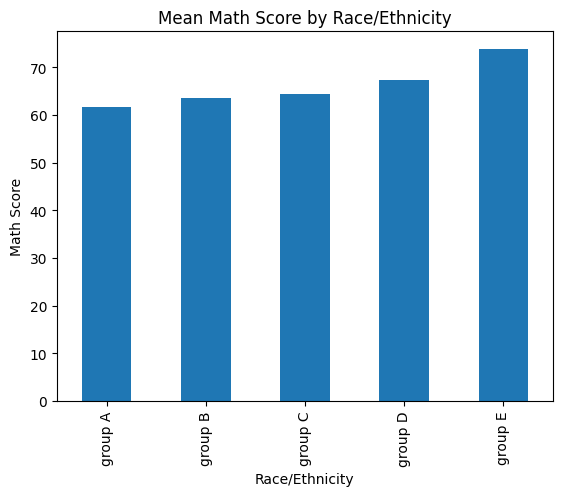

In [ ]:
#@title Rata-rata math score berdasarkan race/ethnicity
mean_math_race = df.groupby('race/ethnicity')['math score'].mean()

mean_math_race.plot(kind='bar')
plt.title('Mean Math Score by Race/Ethnicity')
plt.ylabel('Math Score')
plt.xlabel('Race/Ethnicity')
plt.show()


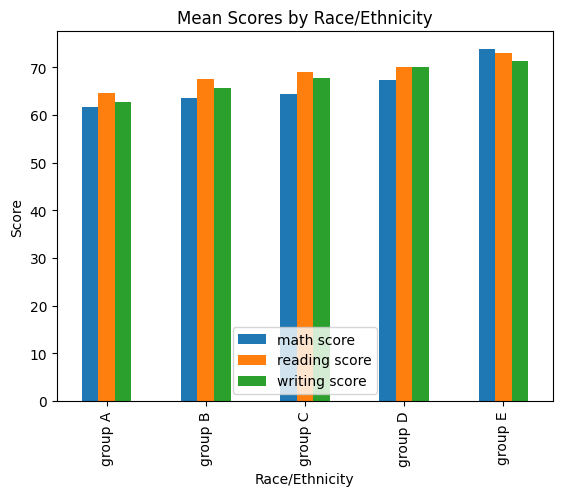

In [ ]:
#@title Rata-rata math score, reading score, dan writing score berdasarkan race/ethnicity
meanscore = df.groupby('race/ethnicity')[['math score','reading score','writing score']].mean()

meanscore.plot(kind='bar')
plt.title('Mean Scores by Race/Ethnicity')
plt.ylabel('Score')
plt.xlabel('Race/Ethnicity')
plt.show()


<Axes: title={'center': 'Average Scores by Gender'}, xlabel='gender'>

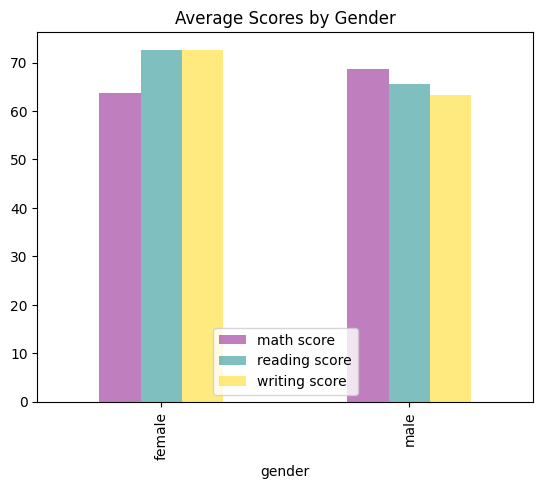

In [ ]:
meanGender = df.groupby('gender')[['math score','reading score','writing score']].mean()

meanGender.plot(
    kind='bar',
    color=['purple', 'teal', 'gold'],  # math, reading, writing
    alpha=0.5,
    title='Average Scores by Gender'
)

### **Tugas di Kelas (mini-project 20–30 menit) — *Dataset Bebas***

1.  **Cari dataset publik** (Kaggle / UCI / Google Dataset Search / data.go.id).
**Syarat:** ≥5 kolom, ada variabel **numerik** & **kategorik**.

2. **Load data** ke DataFrame `df`

3. **Rapikan data**

* Pastikan tiap baris = 1 observasi
* Drop kolom yang tidak diperlukan (jika ada)

4. **Periksa Missing values**
* Hitung null per kolom
* Hapus missing value (jelaskan pilihan)

5. **Manipulating data**

* Buat **≥2 variabel baru** (misalnya total, rasio, log, normalisasi).

6. **Sorting**
* Urutkan berdasarkan variabel numerik utama → tampilkan 10 nilai ekstrem.

7.  **Grouping**
* Hitung **mean/sum/count** berdasarkan ≥1 variabel kategorik.

8. **Pivot table**
* Buat pivot dengan `index` (kategori), `values` (numerik), `aggfunc`.

9.  **Plotting (1 grafik wajib)**
* Bar plot / histogram / boxplot dengan judul informatif.

10. **Penjelasan singkat**
* Observation (unit analisis)
* Variabel
* Skala pengukuran (nominal/ordinal/interval/ratio)

---

### **Output**

1. Kode
2. Output tabel
3. Grafik
4. Interpretasi singkat
